In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

DATA_PATH = os.environ.get(
    "MONETARY_DATA_PATH", os.path.join("..", "data", "Monetary_transmission_data_III.xlsx")
)
FEATURE_COLS = ["CPI", "EXR", "M2b", "RSV", "BRNT"]
TARGET_COLS = ["CPI", "EXR"]
MAXLAGS = 12
MAX_INTEGRATION_ORDER = 2
SIG_LEVEL = 0.05
IRF_PERIODS = 36


def load_data(path: str) -> pd.DataFrame:
    """Load raw Excel data and enforce a sorted monthly DatetimeIndex."""
    df = pd.read_excel(path, parse_dates=["DATE"])
    return df.sort_values("DATE").set_index("DATE").asfreq("MS")


def log_transform(df: pd.DataFrame) -> tuple:
    """Log-transform strictly positive series to stabilize variance; others left as-is."""
    out = df.copy()
    log_cols = [c for c in out.columns if (out[c] > 0).all()]
    out[log_cols] = np.log(out[log_cols])
    return out, log_cols


df_raw = load_data(DATA_PATH)[FEATURE_COLS]
df, LOG_COLS = log_transform(df_raw)
print(f"log-transformed columns: {LOG_COLS}")
df.head()

log-transformed columns: ['CPI', 'EXR', 'M2b', 'RSV', 'BRNT']


,CPI,EXR,M2b,RSV,BRNT
DATE,,,,,
2003-01-01,3.906372,4.572315,13.352670,21.502671,3.427797
2003-02-01,3.895216,4.573282,13.362540,21.525957,3.486228
2003-03-01,3.871867,4.573994,13.373999,21.505301,3.406785
2003-04-01,3.863851,4.574513,13.382558,21.599546,3.220275
2003-05-01,3.887386,4.576902,13.386649,21.586376,3.247057


In [2]:
# Same structural-break windows as the VAR/VECM forecasting notebook.
BREAK_DATES = pd.to_datetime(["2008-06-01", "2016-10-01", "2022-03-01"])
EDGES = [df.index.min(), *BREAK_DATES, df.index.max() + pd.DateOffset(days=1)]

WINDOWS = {f"W{i + 1}": (EDGES[i], EDGES[i + 1] - pd.DateOffset(days=1)) for i in range(len(EDGES) - 1)}
WINDOWS["W5"] = (df.index.min(), df.index.max())

for label, (start, end) in WINDOWS.items():
    print(f"{label}: {start.date()} -> {end.date()} ({len(df.loc[start:end])} months)")

W1: 2003-01-01 -> 2008-05-31 (65 months)
W2: 2008-06-01 -> 2016-09-30 (100 months)
W3: 2016-10-01 -> 2022-02-28 (65 months)
W4: 2022-03-01 -> 2025-10-01 (44 months)
W5: 2003-01-01 -> 2025-10-01 (274 months)


In [3]:
def is_stationary(series: pd.Series, sig_level: float = SIG_LEVEL) -> bool:
    """Stationary only if ADF rejects a unit root and KPSS fails to reject stationarity."""
    s = series.dropna()
    try:
        adf_p = adfuller(s, autolag="AIC")[1]
    except Exception:
        adf_p = 1.0
    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = 0.0
    return adf_p < sig_level and kpss_p >= sig_level


def integration_order(series: pd.Series, max_order: int = MAX_INTEGRATION_ORDER, sig_level: float = SIG_LEVEL) -> int:
    """Smallest d such that the d-th difference is stationary by ADF+KPSS agreement."""
    s = series
    for d in range(max_order + 1):
        if is_stationary(s, sig_level):
            return d
        s = s.diff().dropna()
    return max_order


def stationarity_report(train: pd.DataFrame) -> pd.Series:
    """Integration order per series on the training portion of a window."""
    return pd.Series({col: integration_order(train[col]) for col in train.columns}, name="order")


def select_lag_order(train: pd.DataFrame, maxlags: int) -> int:
    """AIC-optimal VAR order in levels, capped so the model stays identified on short windows."""
    cap = max(1, min(maxlags, len(train) // (len(train.columns) + 1) - 1))
    try:
        order = VAR(train).select_order(cap).aic
    except Exception:
        order = 1
    return max(order, 1)


def stationary_frame(train: pd.DataFrame, orders: pd.Series) -> pd.DataFrame:
    """Difference each series by its integration order to induce stationarity for causality/IR analysis."""
    out = train.copy()
    for col, d in orders.items():
        for _ in range(int(d)):
            out[col] = out[col].diff()
    return out.dropna()


def fit_auxiliary_var(train: pd.DataFrame, orders: pd.Series, maxlags: int = MAXLAGS):
    """Stationary VAR used for Granger causality, FEVD and GIRF."""
    stat_train = stationary_frame(train, orders)
    lag = select_lag_order(stat_train, maxlags)
    return VAR(stat_train).fit(lag)

In [6]:
def granger_causality_table(fitted_var) -> pd.DataFrame:
    """Long-format pairwise Granger causality F-test p-values: does `causing` Granger-cause `caused`."""
    names = fitted_var.names
    rows = [
        {"caused": caused, "causing": causing,
         "pvalue": fitted_var.test_causality(caused, [causing], kind="f").pvalue}
        for caused in names for causing in names if caused != causing
    ]
    return pd.DataFrame(rows)


def fevd_table(fitted_var, periods: int = IRF_PERIODS) -> pd.DataFrame:
    """Long-format forecast error variance decomposition: share of each response's variance by shock, per horizon."""
    decomp = fitted_var.fevd(periods).decomp
    names = fitted_var.names
    return pd.DataFrame([
        {"horizon": h + 1, "response": names[i], "shock": names[j], "share": decomp[i, h, j]}
        for i in range(len(names)) for h in range(periods) for j in range(len(names))
    ])


def girf_table(fitted_var, periods: int = IRF_PERIODS) -> pd.DataFrame:
    """Long-format generalized impulse responses (Pesaran-Shin), invariant to variable ordering."""
    ma_coefs = fitted_var.ma_rep(periods)
    sigma_u = np.asarray(fitted_var.sigma_u)
    scale = np.sqrt(np.diag(sigma_u))
    names = fitted_var.names
    rows = []
    for h, psi_h in enumerate(ma_coefs):
        response = (np.asarray(psi_h) @ sigma_u) / scale
        rows.extend(
            {"horizon": h, "response": names[i], "shock": names[j], "value": response[i, j]}
            for i in range(len(names)) for j in range(len(names))
        )
    return pd.DataFrame(rows)

In [7]:
analysis = {}
for label, (start, end) in WINDOWS.items():
    train = df.loc[start:end]
    orders = stationarity_report(train)
    fitted_var = fit_auxiliary_var(train, orders)
    analysis[label] = {
        "granger": granger_causality_table(fitted_var),
        "fevd": fevd_table(fitted_var),
        "girf": girf_table(fitted_var),
    }
    print(f"{label}: auxiliary VAR lag={fitted_var.k_ar}")
    display(analysis[label]["granger"].pivot(index="caused", columns="causing", values="pvalue"))

W1: auxiliary VAR lag=9


causing,BRNT,CPI,EXR,M2b,RSV
caused,,,,,
BRNT,NaN,0.993983,0.553632,0.570510,0.724485
CPI,0.228070,NaN,0.203947,0.064441,0.057438
EXR,0.641539,0.923476,NaN,0.684752,0.541717
M2b,0.566725,0.812465,0.518083,NaN,0.479294
RSV,0.604081,0.480742,0.640252,0.842367,NaN


W2: auxiliary VAR lag=1


causing,BRNT,CPI,EXR,M2b,RSV
caused,,,,,
BRNT,NaN,0.382087,0.816427,0.263870,0.357250
CPI,0.012776,NaN,0.579661,0.927278,0.424877
EXR,0.499435,0.851726,NaN,0.208715,0.015123
M2b,0.296744,0.759691,0.344863,NaN,0.370149
RSV,0.098859,0.045080,0.212709,0.024709,NaN


W3: auxiliary VAR lag=9


causing,BRNT,CPI,EXR,M2b,RSV
caused,,,,,
BRNT,NaN,0.981557,0.672839,0.694470,0.704605
CPI,0.948860,NaN,0.959305,0.977245,0.779874
EXR,0.087550,0.847167,NaN,0.792903,0.618587
M2b,0.032258,0.140530,0.140387,NaN,0.080204
RSV,0.823734,0.302265,0.595106,0.835987,NaN


W4: auxiliary VAR lag=6


causing,BRNT,CPI,EXR,M2b,RSV
caused,,,,,
BRNT,NaN,0.816143,0.248911,0.695404,0.069901
CPI,0.600796,NaN,0.606437,0.821798,0.624191
EXR,0.801871,0.709039,NaN,0.664204,0.523774
M2b,0.136337,0.381521,0.068863,NaN,0.053452
RSV,0.880320,0.402204,0.825190,0.373005,NaN


W5: auxiliary VAR lag=3


causing,BRNT,CPI,EXR,M2b,RSV
caused,,,,,
BRNT,NaN,0.267986,2.803886e-01,0.834599,0.594883
CPI,0.001549,NaN,6.627157e-10,0.435798,0.868029
EXR,0.188373,0.656388,NaN,0.000764,0.000003
M2b,0.247260,0.140905,8.181314e-06,NaN,0.315726
RSV,0.051109,0.956745,8.594262e-01,0.304727,NaN


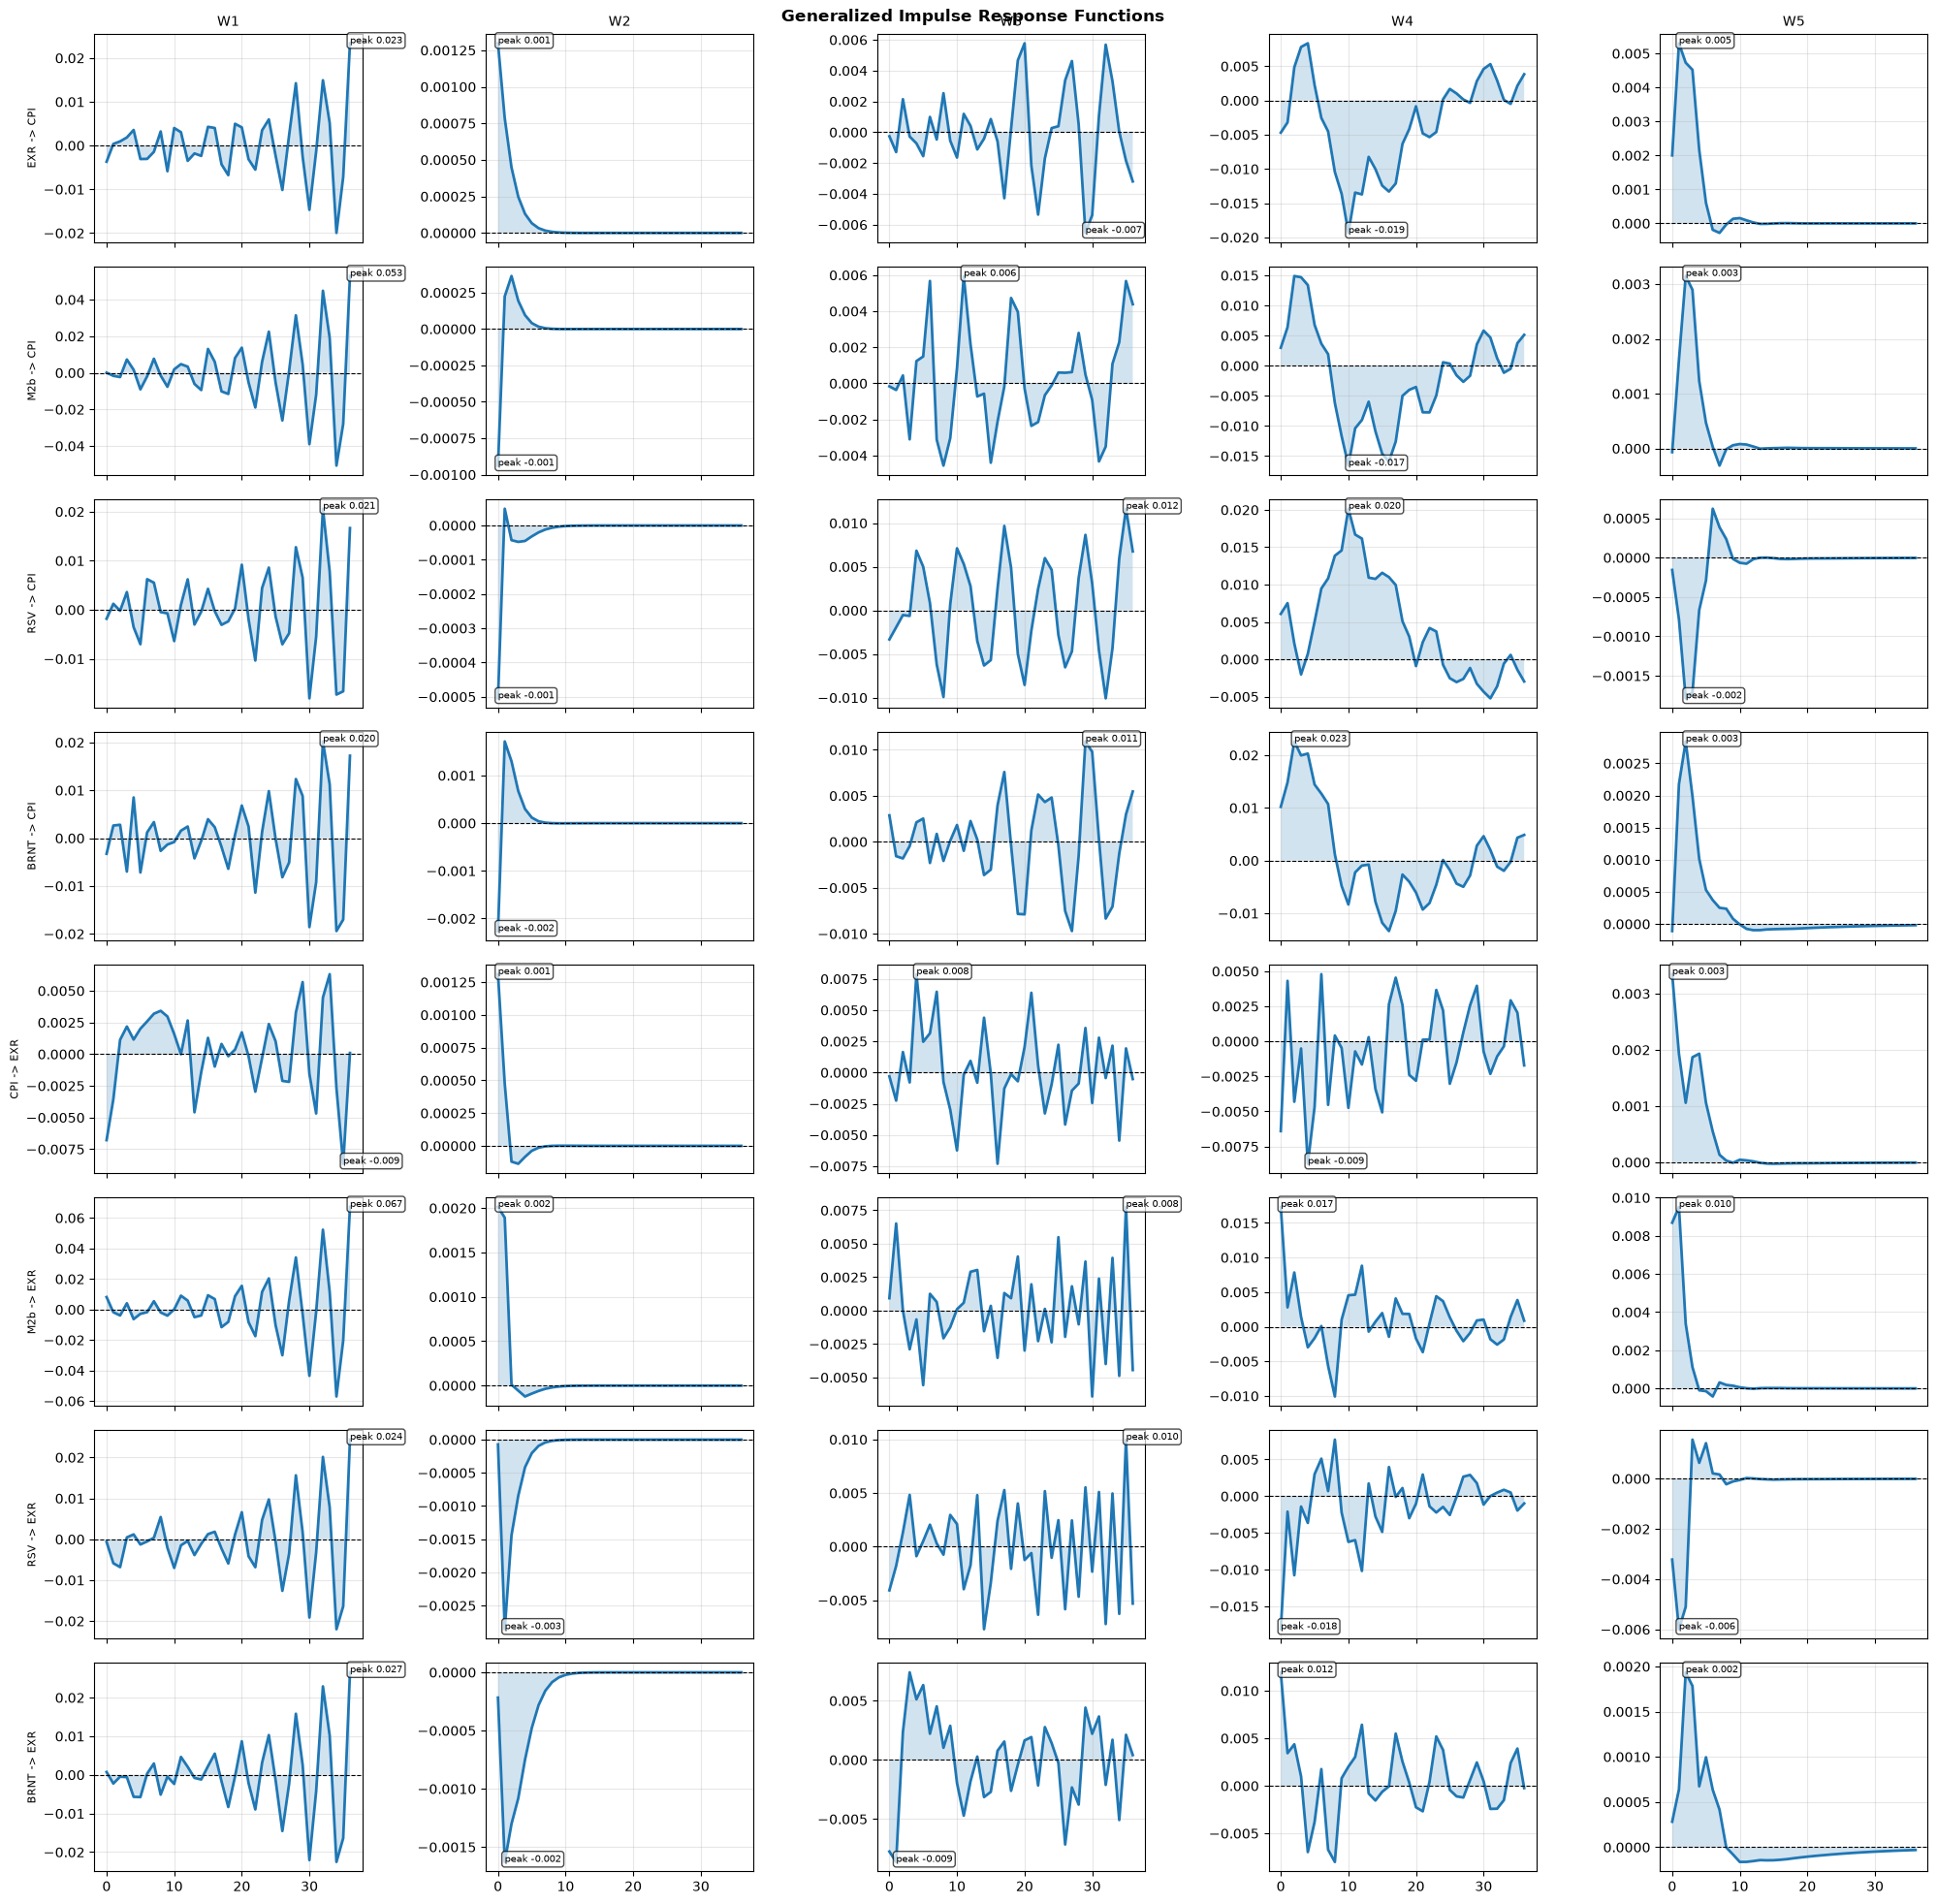

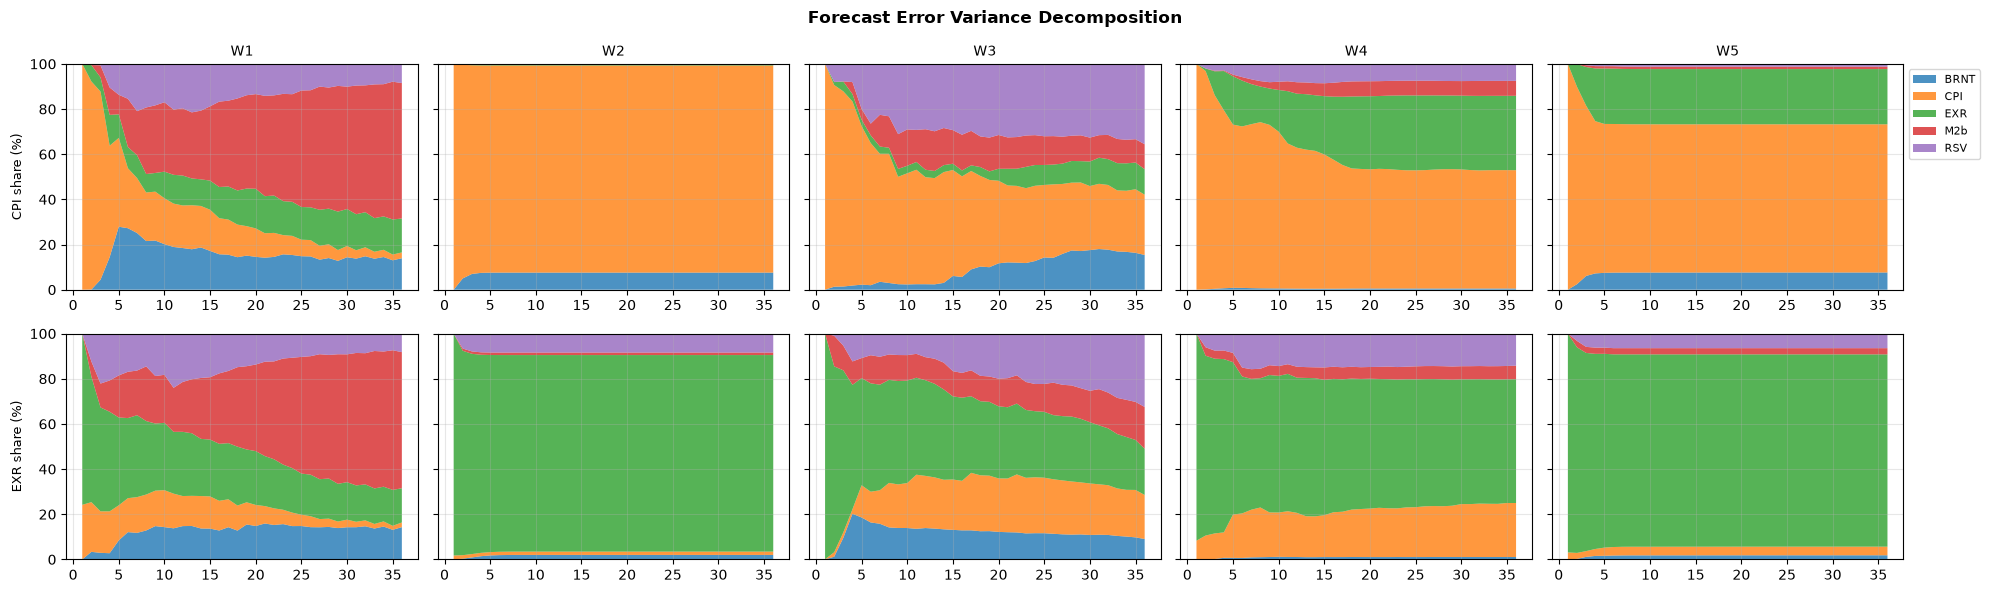

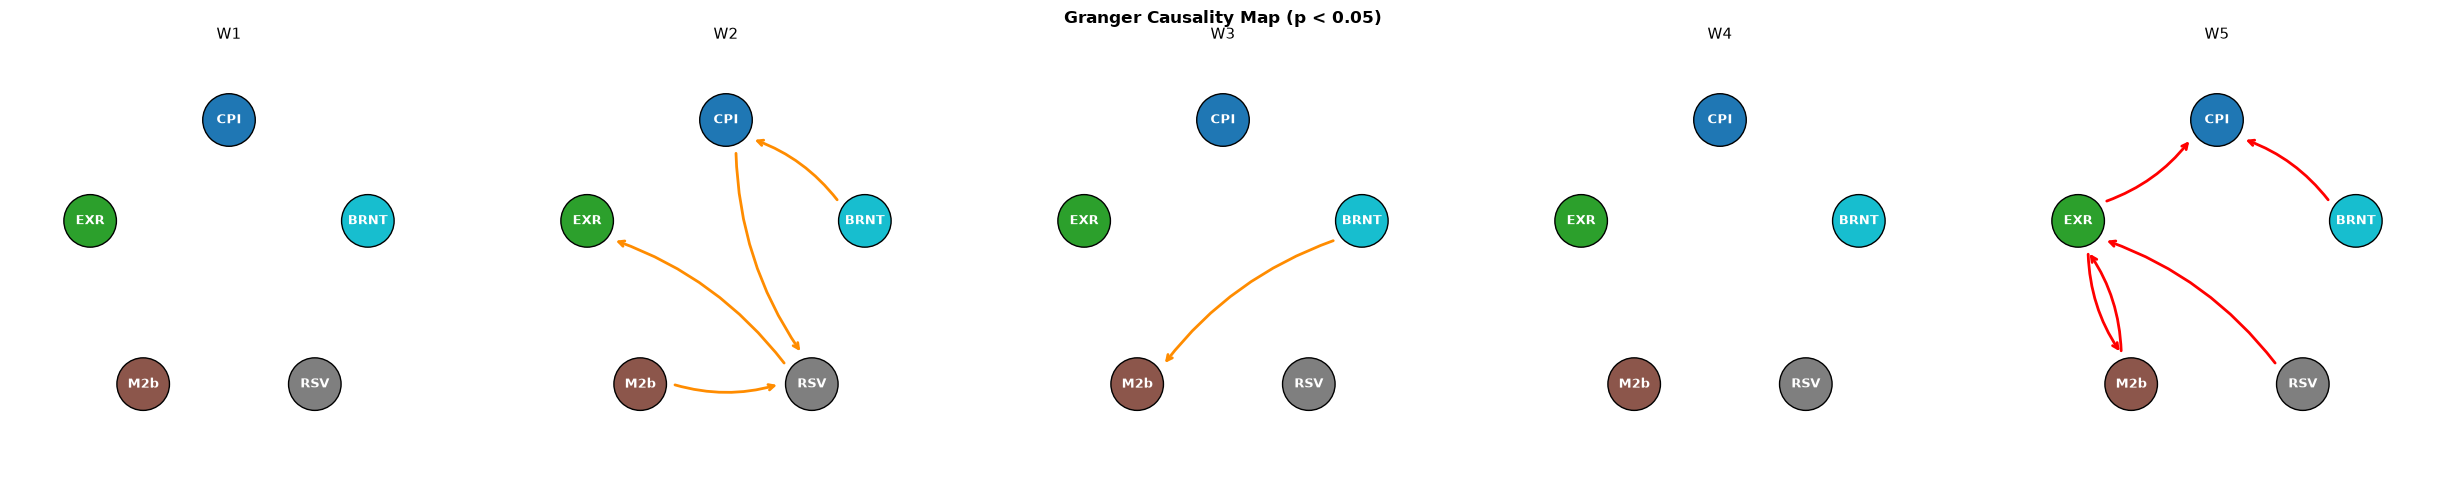

In [8]:
KEY_CHANNELS = [(shock, resp) for resp in TARGET_COLS for shock in FEATURE_COLS if shock != resp]


def plot_girf_grid(analysis: dict, channels: list = KEY_CHANNELS) -> None:
    """Grid of generalized impulse responses (rows=shock->response channels, cols=windows)."""
    fig, axes = plt.subplots(len(channels), len(analysis),
                              figsize=(4 * len(analysis), 2.5 * len(channels)), sharex=True)
    for row, (shock, resp) in enumerate(channels):
        for col, (label, a) in enumerate(analysis.items()):
            ax = axes[row, col]
            sub = (a["girf"][(a["girf"]["shock"] == shock) & (a["girf"]["response"] == resp)]
                   .sort_values("horizon"))
            ax.plot(sub["horizon"], sub["value"], lw=2)
            ax.fill_between(sub["horizon"], 0, sub["value"], alpha=0.2)
            ax.axhline(0, color="black", ls="--", lw=0.8)
            peak = sub.loc[sub["value"].abs().idxmax()]
            ax.annotate(f"peak {peak['value']:.3f}", xy=(peak["horizon"], peak["value"]),
                        fontsize=7, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
            if row == 0:
                ax.set_title(label, fontsize=10)
            if col == 0:
                ax.set_ylabel(f"{shock} -> {resp}", fontsize=8)
            ax.grid(alpha=0.3)
    plt.suptitle("Generalized Impulse Response Functions", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../results/girf.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_fevd_grid(analysis: dict, targets: list = TARGET_COLS) -> None:
    """Stacked forecast error variance decomposition (rows=targets, cols=windows)."""
    fig, axes = plt.subplots(len(targets), len(analysis),
                              figsize=(4 * len(analysis), 3 * len(targets)), sharey=True)
    for row, target in enumerate(targets):
        for col, (label, a) in enumerate(analysis.items()):
            ax = axes[row, col]
            pivot = (a["fevd"][a["fevd"]["response"] == target]
                     .pivot(index="horizon", columns="shock", values="share") * 100)
            ax.stackplot(pivot.index, pivot.T.values, labels=pivot.columns, alpha=0.8)
            ax.set_ylim(0, 100)
            if row == 0:
                ax.set_title(label, fontsize=10)
            if col == 0:
                ax.set_ylabel(f"{target} share (%)", fontsize=9)
            ax.grid(alpha=0.3)
    axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
    plt.suptitle("Forecast Error Variance Decomposition", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../results/fevd.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_causality_map(analysis: dict, variables: list = FEATURE_COLS, sig_level: float = SIG_LEVEL) -> None:
    """Directed network of significant Granger-causal links, one panel per window."""
    n = len(variables)
    angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, n, endpoint=False)
    positions = {v: (np.cos(a), np.sin(a)) for v, a in zip(variables, angles)}
    node_colors = dict(zip(variables, plt.cm.tab10(np.linspace(0, 1, n))))

    fig, axes = plt.subplots(1, len(analysis), figsize=(5 * len(analysis), 5))
    axes = np.atleast_1d(axes)
    for ax, (label, a) in zip(axes, analysis.items()):
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect("equal")
        ax.axis("off")
        for var, (x, y) in positions.items():
            ax.add_patch(plt.Circle((x, y), 0.18, color=node_colors[var], ec="black", zorder=5))
            ax.text(x, y, var, ha="center", va="center", fontsize=9,
                     fontweight="bold", color="white", zorder=6)
        for _, row in a["granger"].iterrows():
            if row["pvalue"] >= sig_level:
                continue
            x1, y1 = positions[row["causing"]]
            x2, y2 = positions[row["caused"]]
            dx, dy = x2 - x1, y2 - y1
            dist = np.hypot(dx, dy)
            ux, uy = dx / dist, dy / dist
            x1s, y1s = x1 + ux * 0.22, y1 + uy * 0.22
            x2s, y2s = x2 - ux * 0.22, y2 - uy * 0.22
            color = "red" if row["pvalue"] < 0.01 else "darkorange"
            ax.annotate("", xy=(x2s, y2s), xytext=(x1s, y1s),
                        arrowprops=dict(arrowstyle="->", color=color, lw=2,
                                         connectionstyle="arc3,rad=0.15"))
        ax.set_title(label, fontsize=11)
    plt.suptitle("Granger Causality Map (p < 0.05)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../results/granger_causality_map.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_girf_grid(analysis)
plot_fevd_grid(analysis)
plot_causality_map(analysis)

In [ ]:
def _with_window(frames: dict) -> pd.DataFrame:
    """Stack per-window long-format tables, tagging each row with its source window."""
    return pd.concat([tbl.assign(window=label) for label, tbl in frames.items()], ignore_index=True)


os.makedirs("../results", exist_ok=True)
_with_window({label: a["granger"] for label, a in analysis.items()}).to_csv(
    "../results/granger_causality.csv", index=False
)
_with_window({label: a["fevd"] for label, a in analysis.items()}).to_csv(
    "../results/fevd.csv", index=False
)
_with_window({label: a["girf"] for label, a in analysis.items()}).to_csv(
    "../results/girf.csv", index=False
)